In [1]:
import torch
import os
import sys

from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy

import numpy as np
import matplotlib.pyplot as plt
import random as rd
import seaborn as sb

2025-07-31 13:28:37.540179: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-31 13:28:37.737240: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-07-31 13:28:38.719778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
exp_id = 0
exp_name = "MNIST"
batch_size = 256
data_path = os.getcwd() + "/data/MNIST"
train_correlation, test_correlation = 0.9, 0.1
epochs = 20

In [3]:
current_path = os.getcwd()
train_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=train_correlation, train=True)
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=test_correlation, train=False)

for X, y, _ in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import src.model_utils as mu

model = mu.CMNISTNeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
model

Shape of X [N, C, H, W]: torch.Size([256, 3, 28, 28])
Shape of y: torch.Size([256]) torch.int64
Using cuda device


CMNISTNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
  )
  (l2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (l3): Sequential(
    (0): Linear(in_features=512, out_features=10, bias=True)
  )
)

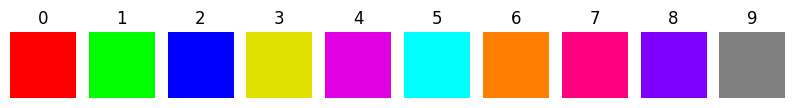

In [4]:
COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]
fig, axes = plt.subplots(1,10, figsize=(10,10))
for label, color in enumerate(COLOUR_MAP):
    axes[label].set_axis_off()
    axes[label].set_title(loc="center", label=f"{label}")
    axes[label].imshow([[color]])

In [5]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y, _) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (batch *batch_size)% 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

accuracy_matrixes = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    accuracy_matrixes.append(test(test_dataloader, model, loss_fn))
print("Done!")

torch.save(model.state_dict(), f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}")
print("Saved under" + f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}")

Epoch 1
-------------------------------
loss: 2.312569  [  256/60000]
loss: 0.371862  [ 6656/60000]
loss: 0.217524  [13056/60000]
loss: 0.231491  [19456/60000]
loss: 0.128446  [25856/60000]
loss: 0.165387  [32256/60000]
loss: 0.128687  [38656/60000]
loss: 0.210281  [45056/60000]
loss: 0.074979  [51456/60000]
loss: 0.103889  [57856/60000]
Test Error: 
 Accuracy: 69.9%, Avg loss: 0.985162 

Epoch 2
-------------------------------
loss: 0.118554  [  256/60000]
loss: 0.090319  [ 6656/60000]
loss: 0.093637  [13056/60000]
loss: 0.088622  [19456/60000]
loss: 0.093887  [25856/60000]
loss: 0.091716  [32256/60000]
loss: 0.133118  [38656/60000]
loss: 0.085040  [45056/60000]
loss: 0.103296  [51456/60000]
loss: 0.072693  [57856/60000]
Test Error: 
 Accuracy: 82.9%, Avg loss: 0.516125 

Epoch 3
-------------------------------
loss: 0.036135  [  256/60000]
loss: 0.093323  [ 6656/60000]
loss: 0.124009  [13056/60000]
loss: 0.063357  [19456/60000]
loss: 0.076101  [25856/60000]
loss: 0.083843  [32256/600

<Axes: >

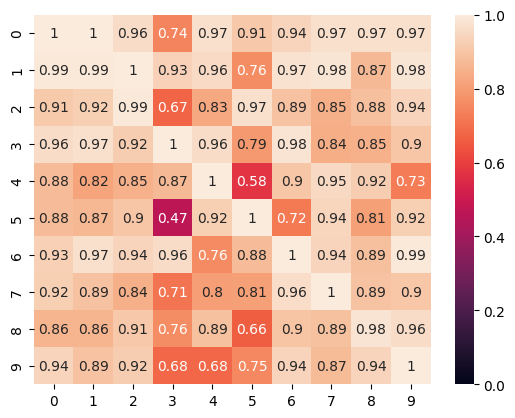

In [6]:
sb.heatmap(accuracy_matrixes[-1], vmin=0, vmax=1, annot=True)